# Importation

In [1]:
# LES ALGORITHMES
# Pour StableBaselines
from QLearning import *
from DQN import *
from PPO import *
from helperPlot import *

# Pour RLLib
from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from ray import train, tune
from rllib_helper import *

# Aide
import time
from pprint import pprint

# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

# Environnements

Ce premier labyrinthe ne donne qu'une unique récompense en cas de sortie de l'agent du labyrinthe.

In [2]:
class FrozenLakeEnv(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLakeEnv, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.width * self.height)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        return self.state, {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = 0
        else :
            reward = 0
        return self.state, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x
    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

Le second environnement ajoute les récompenses négatives à chaque pas et à chaque fois que l'agent tombe dans un trou.

In [3]:
class FrozenLake2Env(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLake2Env, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.width * self.height)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        return self.state, {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = -1
        else :
            reward = -1/(self.width * self.height)
        return self.state, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x
    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

Dans le troisième environnement, l'agent perçoit les cases adjacentes à sa position.

In [4]:
class FrozenLake3Env(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLake3Env, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.cell_values = {'F' : 0, 'S' : 0, 'H' : 1, 'G' : 2, 'W' : 3}
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.MultiDiscrete([self.width * self.height, 4, 4, 4, 4])
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        

    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break


        left, down, right, up = self._getNeighbors(self.state)
        return np.array([self.state, left, down, right, up]), {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = -1
        else :
            reward = -1/(self.width * self.height)

        left, down, right, up = self._getNeighbors(self.state)
        return np.array([self.state, left, down, right, up]), reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x

    def _getNeighbors(self, state) :
        x, y = self._stateToCoordinate(state)
        if x == 0 :  # Retrieve left cell
            left = self.cell_values['W']
        else :
            left = self.cell_values[self.map[y][x-1]]

        if y == self.height -1 :  # Retrieve down cell
            down = self.cell_values["W"]
        else :
            down = self.cell_values[self.map[y+1][x]]

        if x == self.width -1 :   # Retrieve right cell
            right = self.cell_values["W"]
        else :
            right = self.cell_values[self.map[y][x+1]]

        if y == 0 :   # Retrieve up cell
            up = self.cell_values["W"]
        else :
            up = self.cell_values[self.map[y-1][x]]

        return left, down, right, up


    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

Dans ce quatrième épisode, la position est codée par deux neurones qui envoient les coordonnées de l'agent.

In [5]:
class FrozenLake4Env(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLake4Env, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.cell_values = {'F' : 0, 'S' : 0, 'H' : 1, 'G' : 2, 'W' : 3}
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Dict({
            'row_position' : spaces.Box(low = 0, high = self.width - 1, dtype = int),
            'col_position' : spaces.Box(low = 0, high = self.height - 1, dtype = int),
            'left_neighbor' : spaces.Discrete(4),
            'down_neighbor' : spaces.Discrete(4),
            'right_neighbor' : spaces.Discrete(4),
            'up_neighbor' : spaces.Discrete(4)
        })
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        

    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    self.x = x
                    self.y = y
                    break


        left, down, right, up = self._getNeighbors(self.state)
        toReturn = {
            'row_position' : [self.x],
            'col_position' : [self.y],
            'left_neighbor' : left,
            'down_neighbor' : down,
            'right_neighbor' : right,
            'up_neighbor' : up
        }
        return toReturn, {}
    
    def step(self, action) :
        self.x, self.y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if self.x > 0 :
                self.x -= 1
        elif action == 1 : # Down
            if self.y < self.height -1 :
                self.y += 1
        elif action == 2 : # Right
            if self.x < self.width -1 :
                self.x += 1
        elif action == 3 : # Up
            if self.y > 0 :
                self.y -= 1
        
        self.state = self._coordinateToState(self.x, self.y)
        
        result = self.map[self.y][self.x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = -1
        else :
            reward = -1/(self.width * self.height)

        left, down, right, up = self._getNeighbors(self.state)
        toReturn = {
            'row_position' : [self.x],
            'col_position' : [self.y],
            'left_neighbor' : left,
            'down_neighbor' : down,
            'right_neighbor' : right,
            'up_neighbor' : up
        }
        return toReturn, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x

    def _getNeighbors(self, state) :
        x, y = self._stateToCoordinate(state)
        if x == 0 :  # Retrieve left cell
            left = self.cell_values['W']
        else :
            left = self.cell_values[self.map[y][x-1]]

        if y == self.height -1 :  # Retrieve down cell
            down = self.cell_values["W"]
        else :
            down = self.cell_values[self.map[y+1][x]]

        if x == self.width -1 :   # Retrieve right cell
            right = self.cell_values["W"]
        else :
            right = self.cell_values[self.map[y][x+1]]

        if y == 0 :   # Retrieve up cell
            up = self.cell_values["W"]
        else :
            up = self.cell_values[self.map[y-1][x]]

        return left, down, right, up


    
    def render(self, mode = 'human') :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

# Entraînement du DQN de RLlib sur labyrinthe env 1

In [4]:
config = (
    DQNConfig()
    .environment(
        FrozenLakeEnv,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [40000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[8], [32], [128], [16, 16], [64, 64]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-16 14:50:44,710	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=34775) 2025-06-16 14:50:50,194	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=34775) 2025-06-16 14:50:50,881	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `

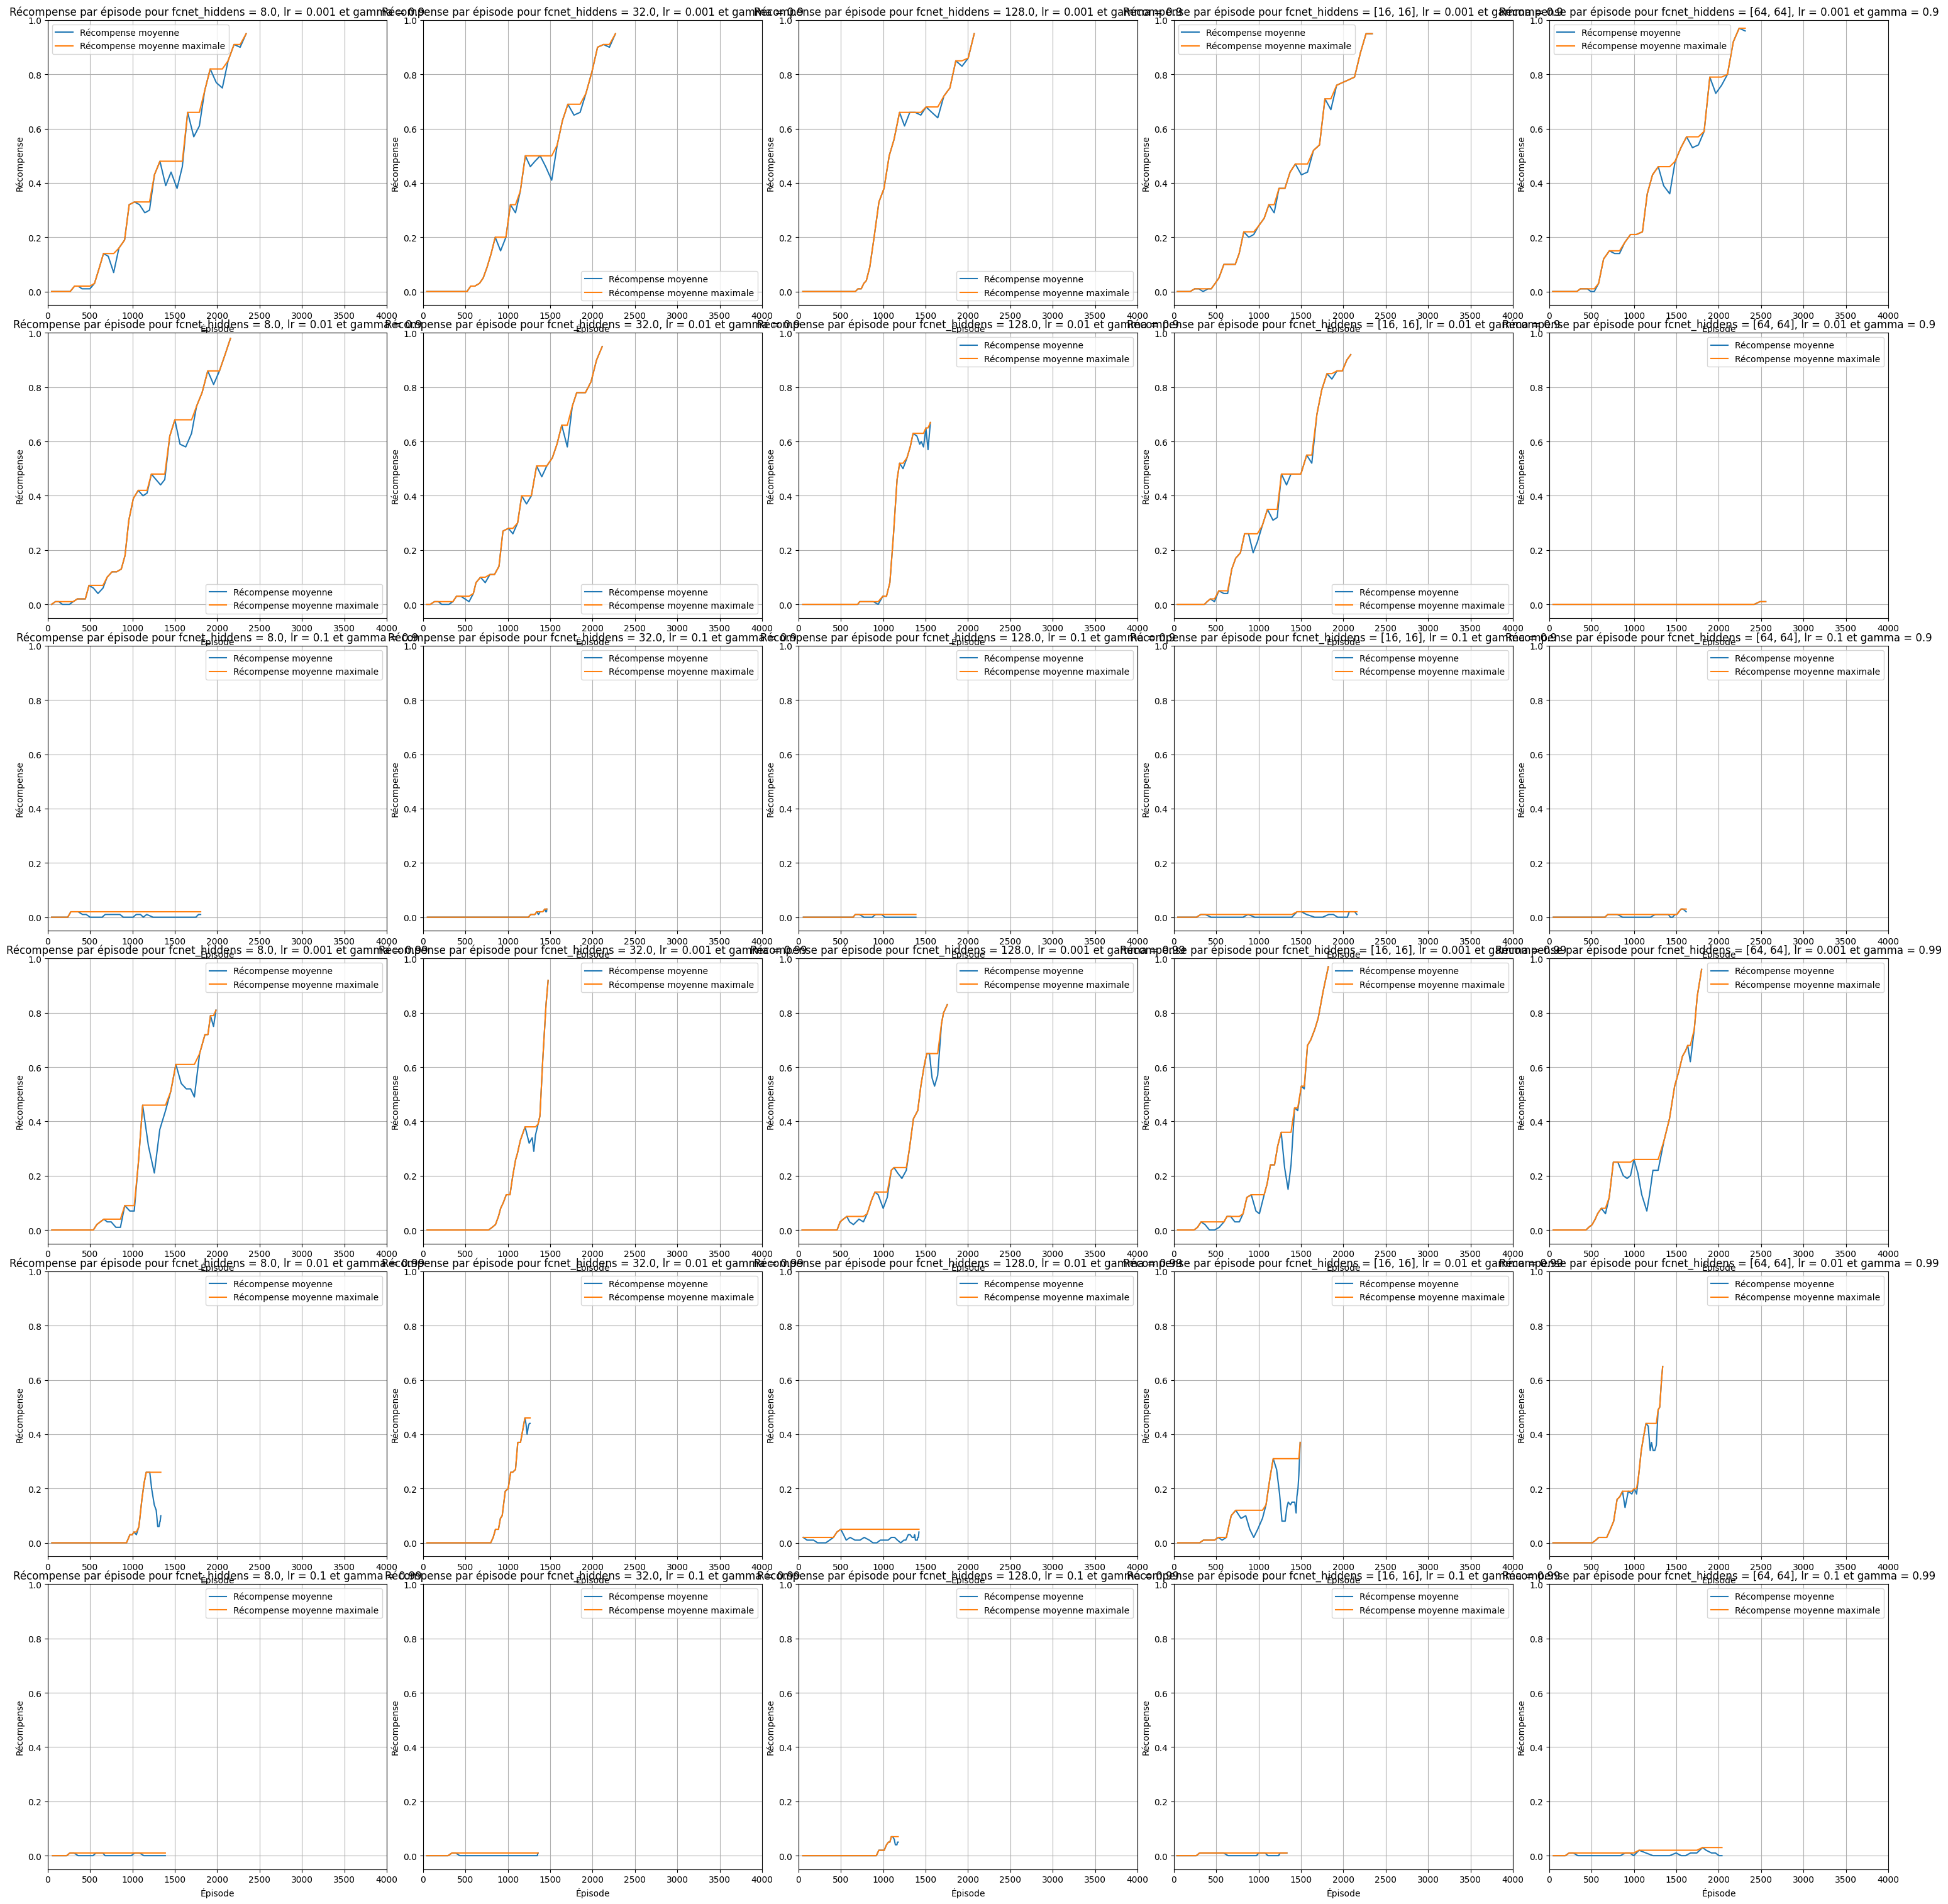

In [13]:
comparison_plot_3(results,
                  "fcnet_hiddens", [8., 32., 128., [16, 16], [64, 64]],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -0.05, 1
                 )

Sans surprise on remarque qu'aucun résultat n'est satisfaisant.
En effet, le comportement du DQN de RLlib est semblable à celui de StableBaselines.

Le problème provient de l'environnement, quelque soit l'implémentation de l'algorithme nous aurons toujours le même soucis.

# DQN pour environnement 2

In [3]:
config = (
    DQNConfig()
    .environment(
        FrozenLake2Env,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [40000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[8], [32], [128], [16, 16], [64, 64]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-17 08:17:25,768	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=5137) 2025-06-17 08:17:31,214	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=5136) 2025-06-17 08:17:32,141	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RL

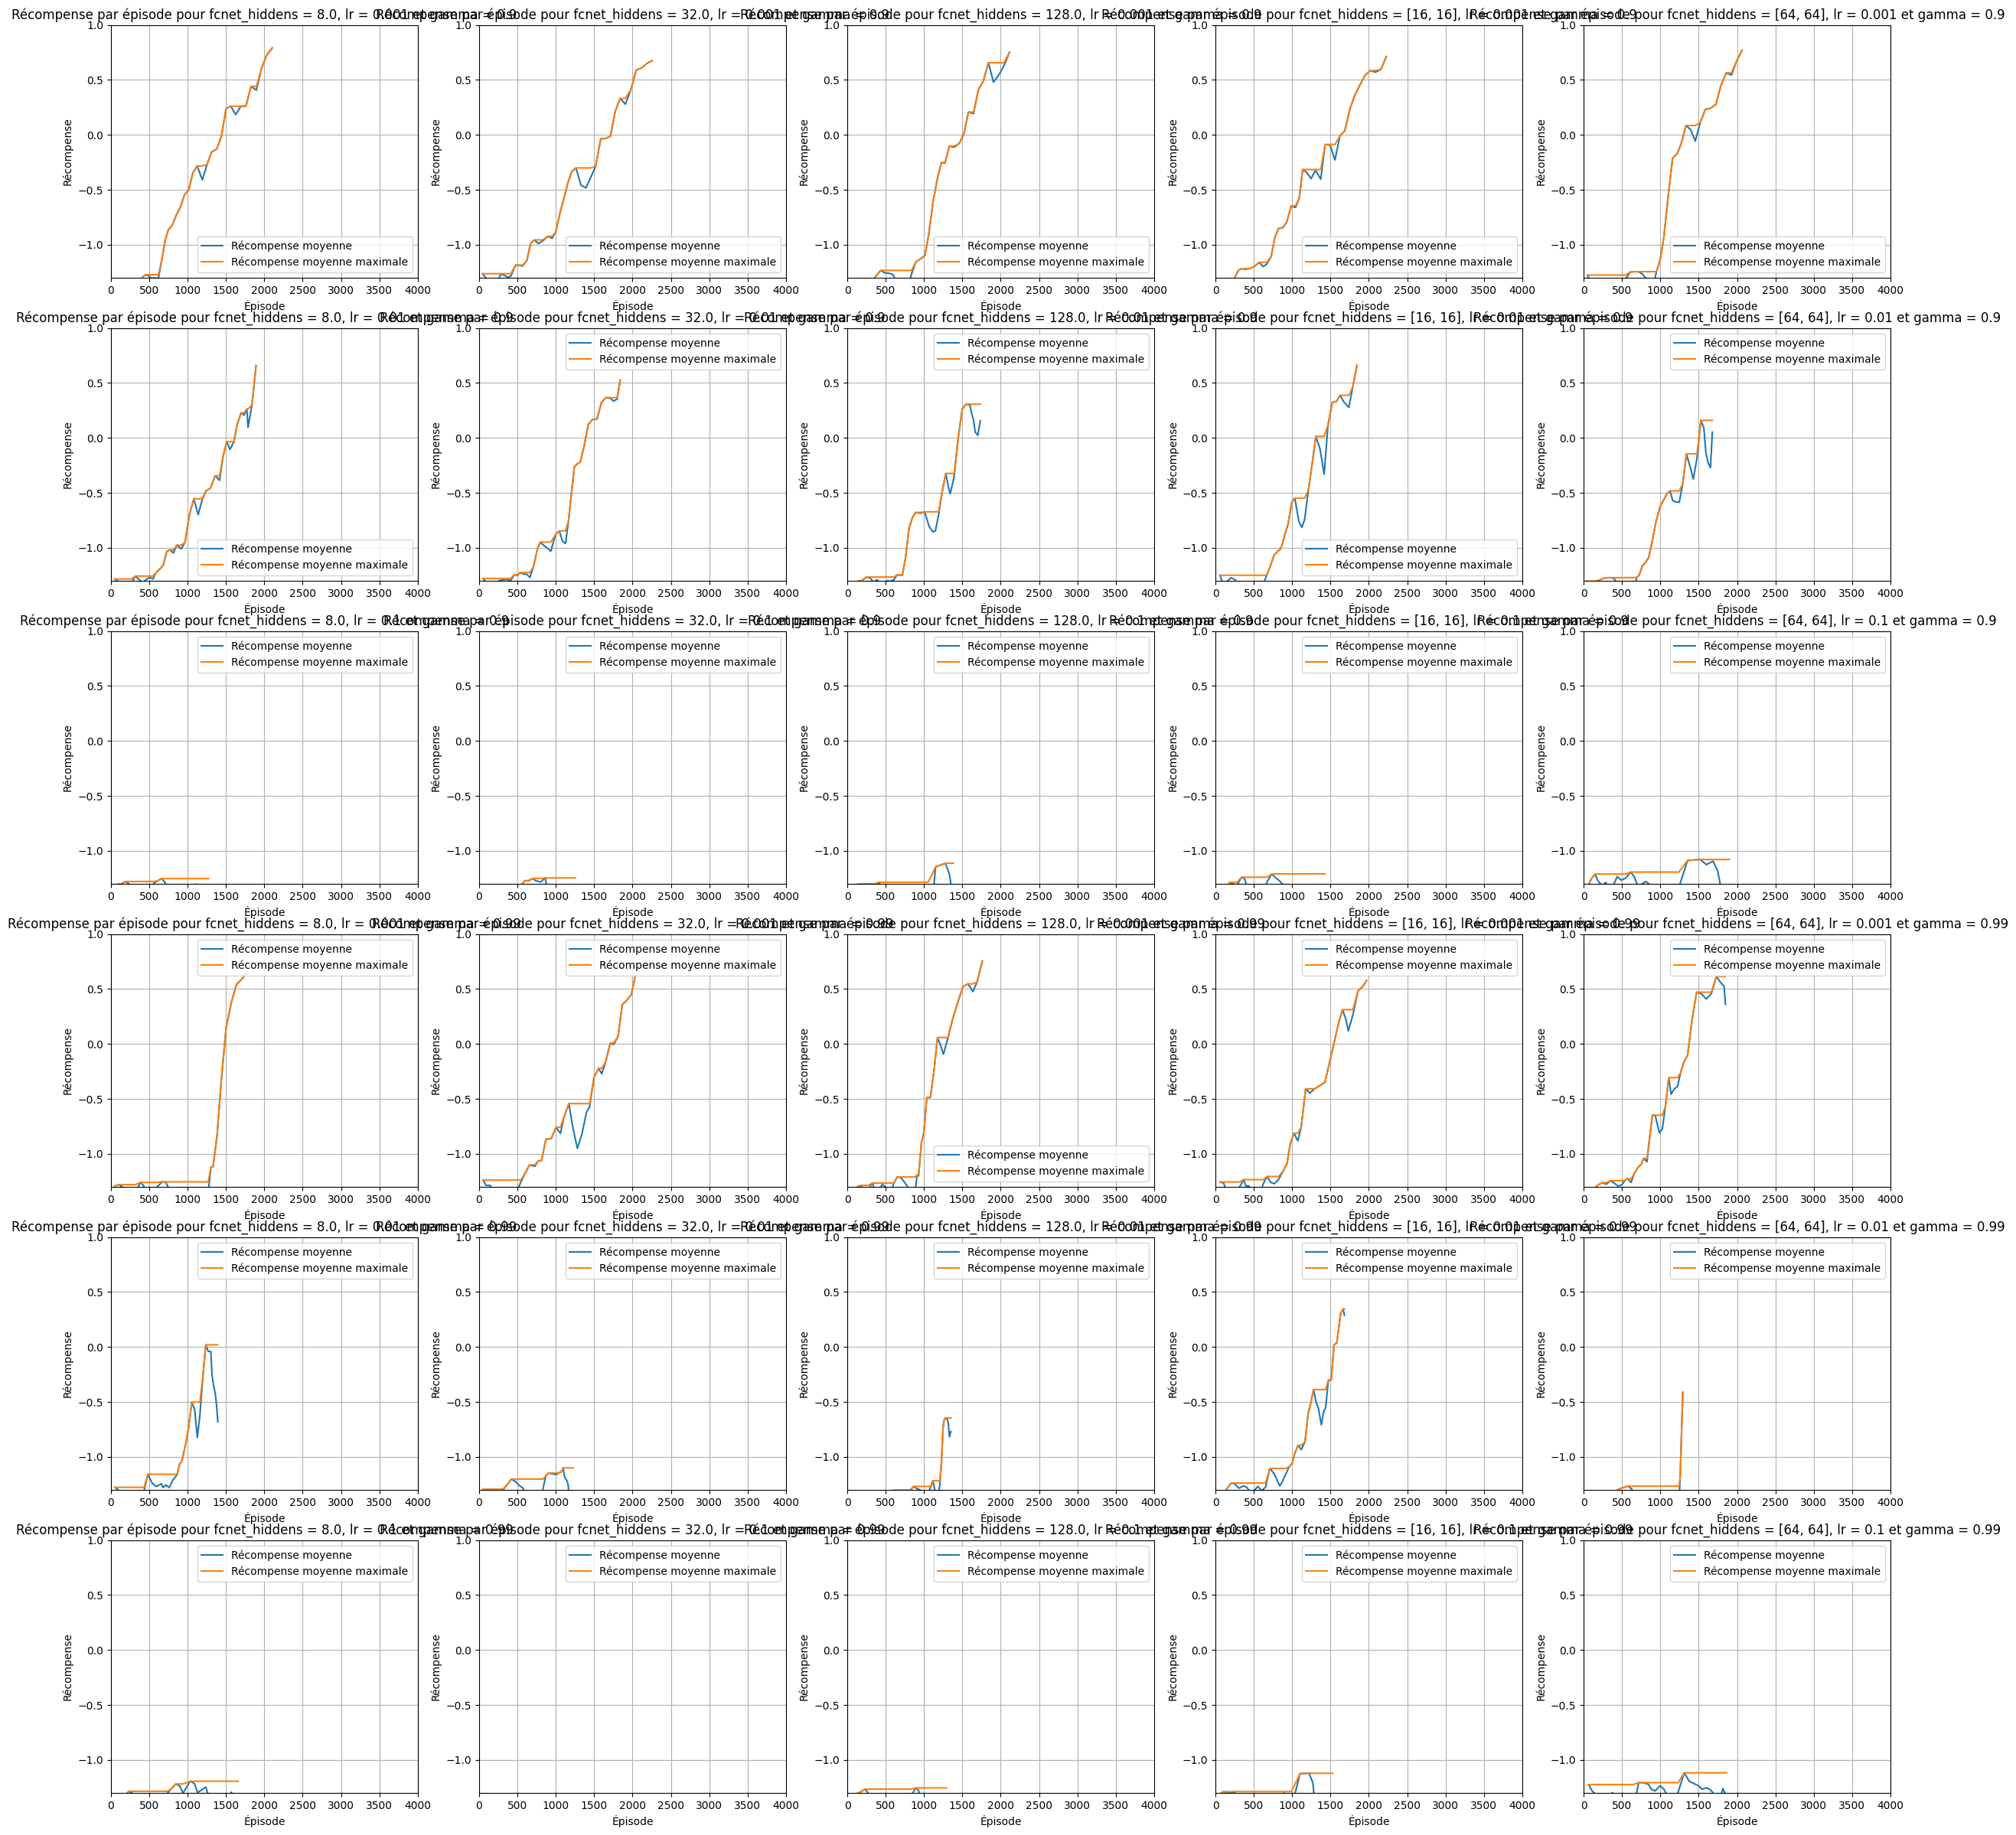

In [4]:
comparison_plot_3(results,
                  "fcnet_hiddens", [8., 32., 128., [16, 16], [64, 64]],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -1.3, 1
                 )

Meilleur résultat pour :

- Architecture de [32]
- lr de 0.001
- gamma de 0.99

# DQN pour environnement 3

In [7]:
config = (
    DQNConfig()
    .environment(
        FrozenLake3Env,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    .training(
        lr = tune.grid_search([0.0001, 0.001, 0.01]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [35000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[16], [32], [64], [16, 16], [32, 32]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-17 13:32:08,767	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/enzo/ray_results/DQN_2025-06-17_11-51-16' in 0.0913s.
2025-06-17 13:32:08,819	INFO tune.py:1041 -- Total run time: 6052.49 seconds (6052.33 seconds for the tuning loop).


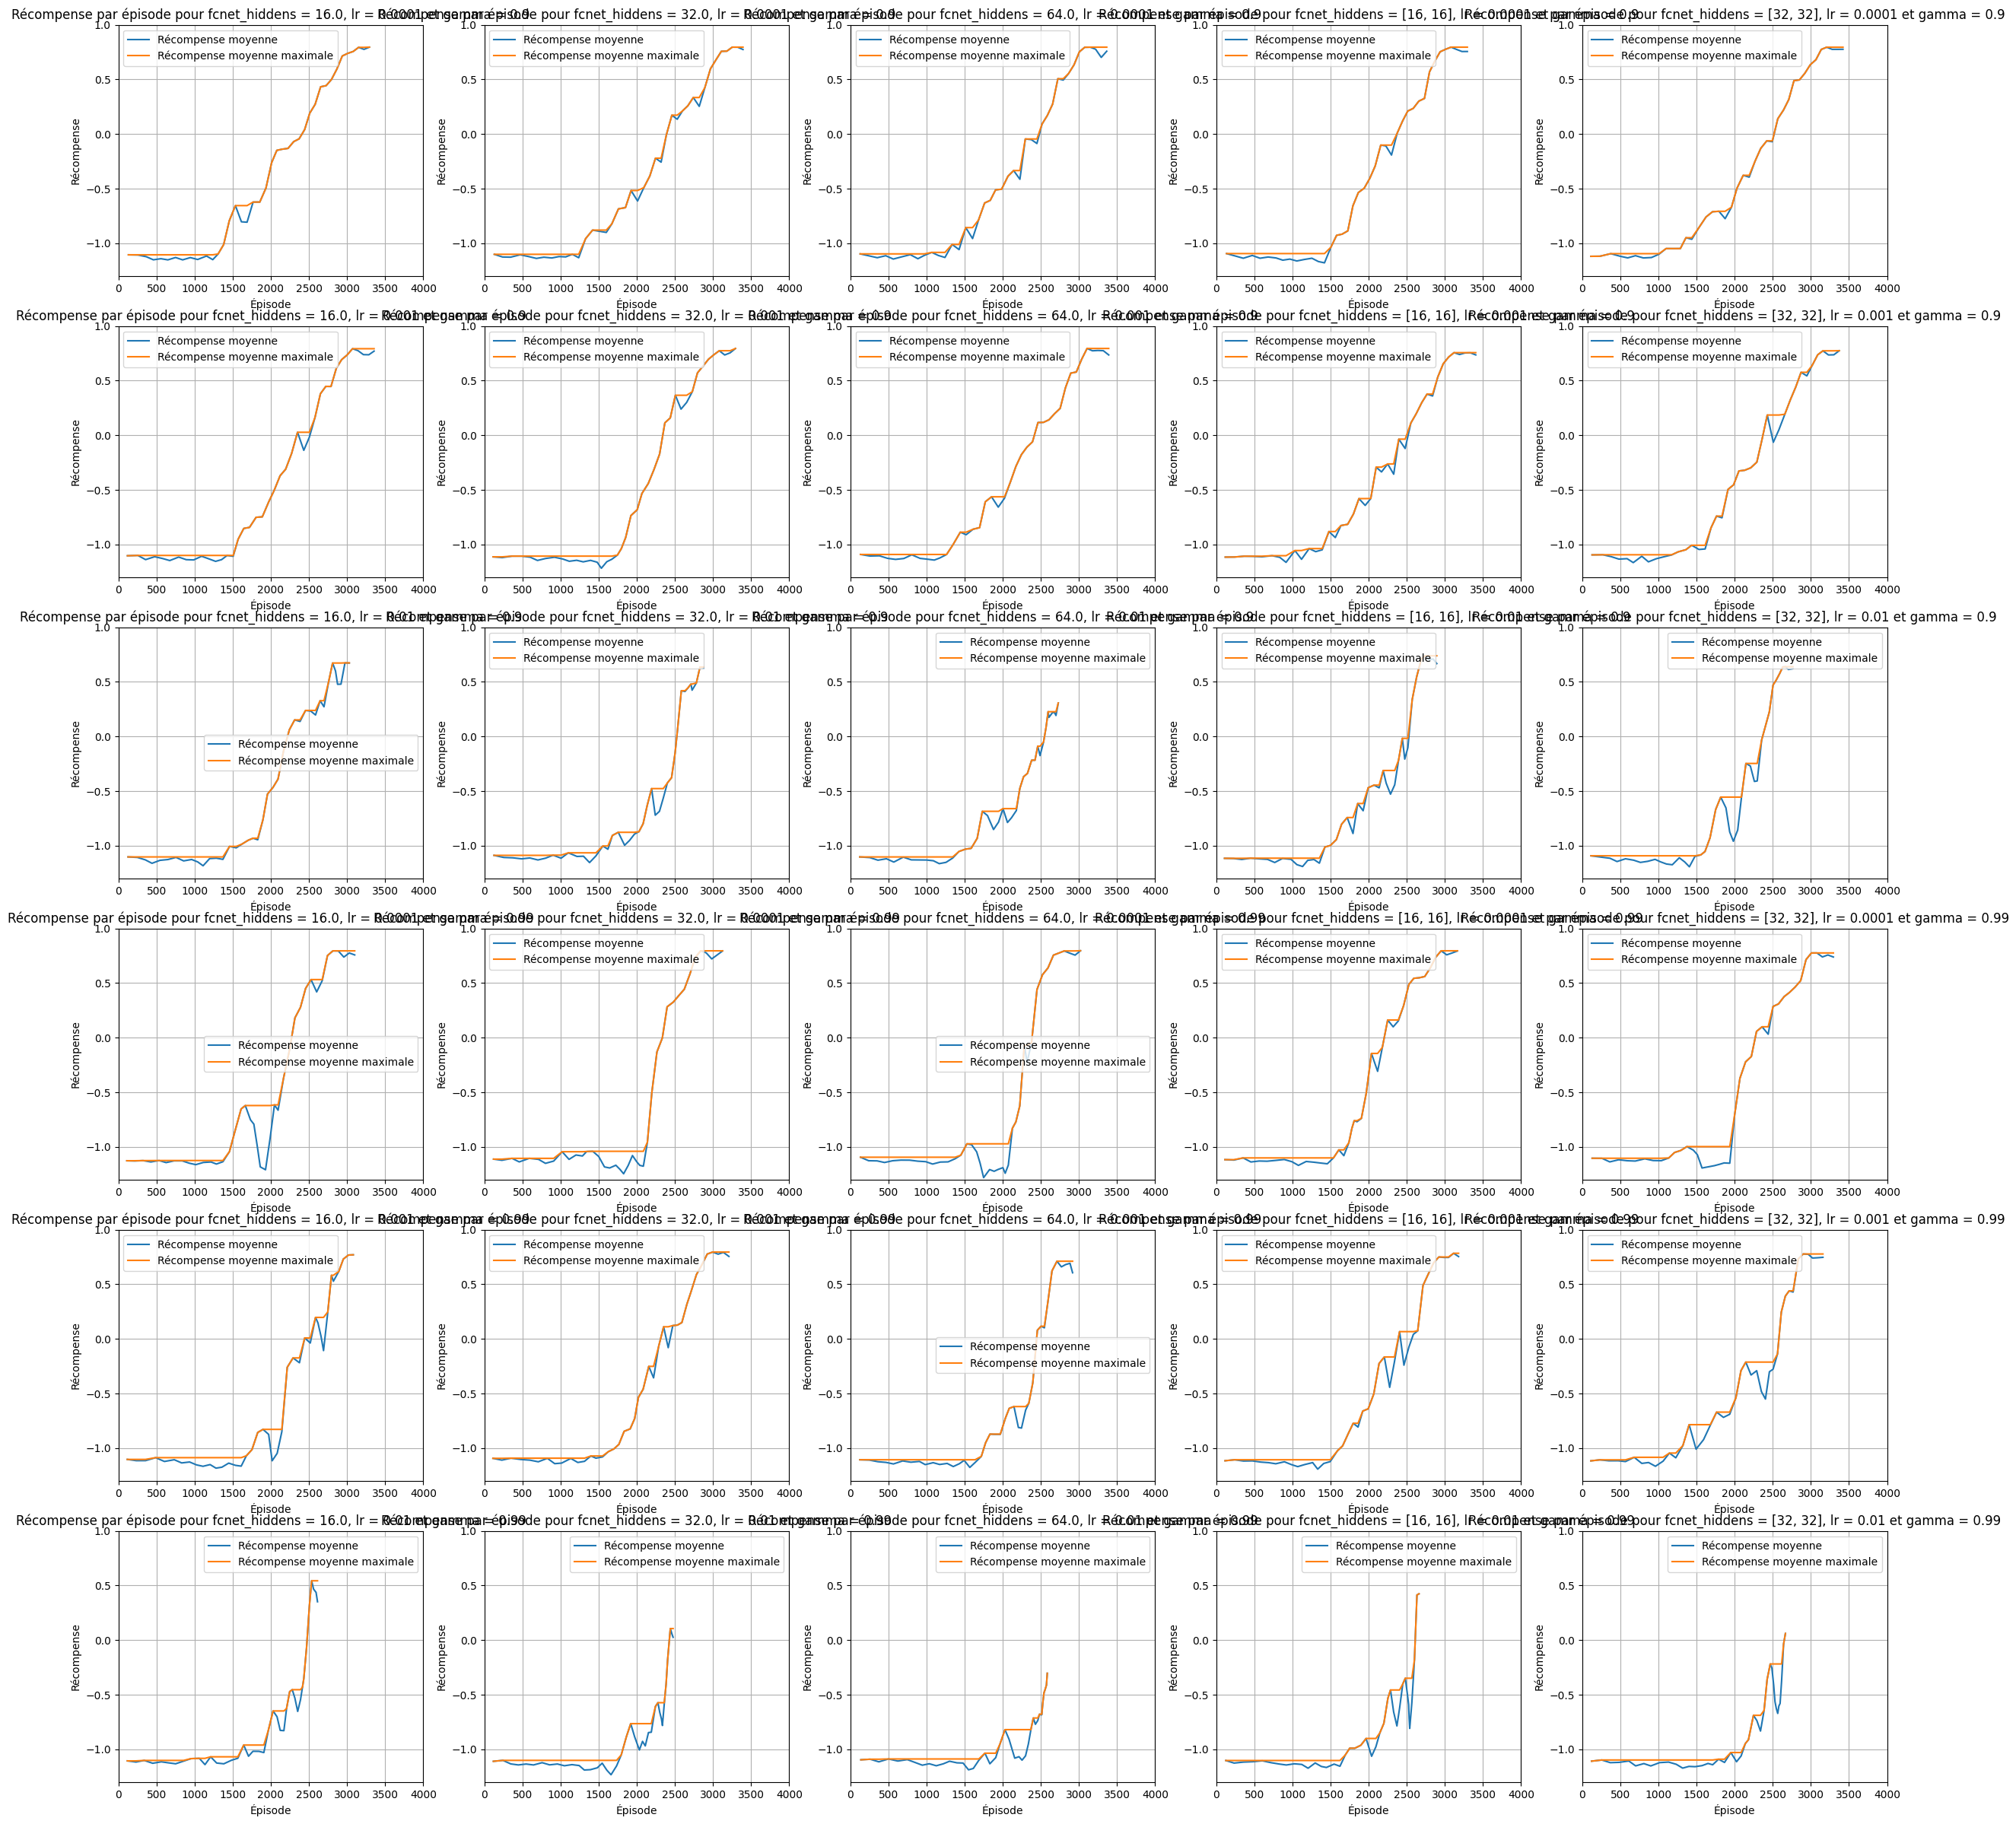

In [8]:
comparison_plot_3(results,
                  "fcnet_hiddens", [16., 32., 64., [16, 16], [32, 32]],
                  "lr", [0.0001, 0.001, 0.01],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -1.3, 1
                 )

Meilleur résultat pour :

- Architecture de [32]
- lr de 0.001
- gamma de 0.99

# DQN pour environnement 4

In [3]:
config = (
    DQNConfig()
    .environment(
        FrozenLake4Env,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    .training(
        lr = tune.grid_search([0.0001, 0.001, 0.01]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [35000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[16], [32], [64], [16, 16], [32, 32]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-17 15:03:05,821	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=49878) 2025-06-17 15:03:11,296	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=49878) 2025-06-17 15:03:12,008	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `

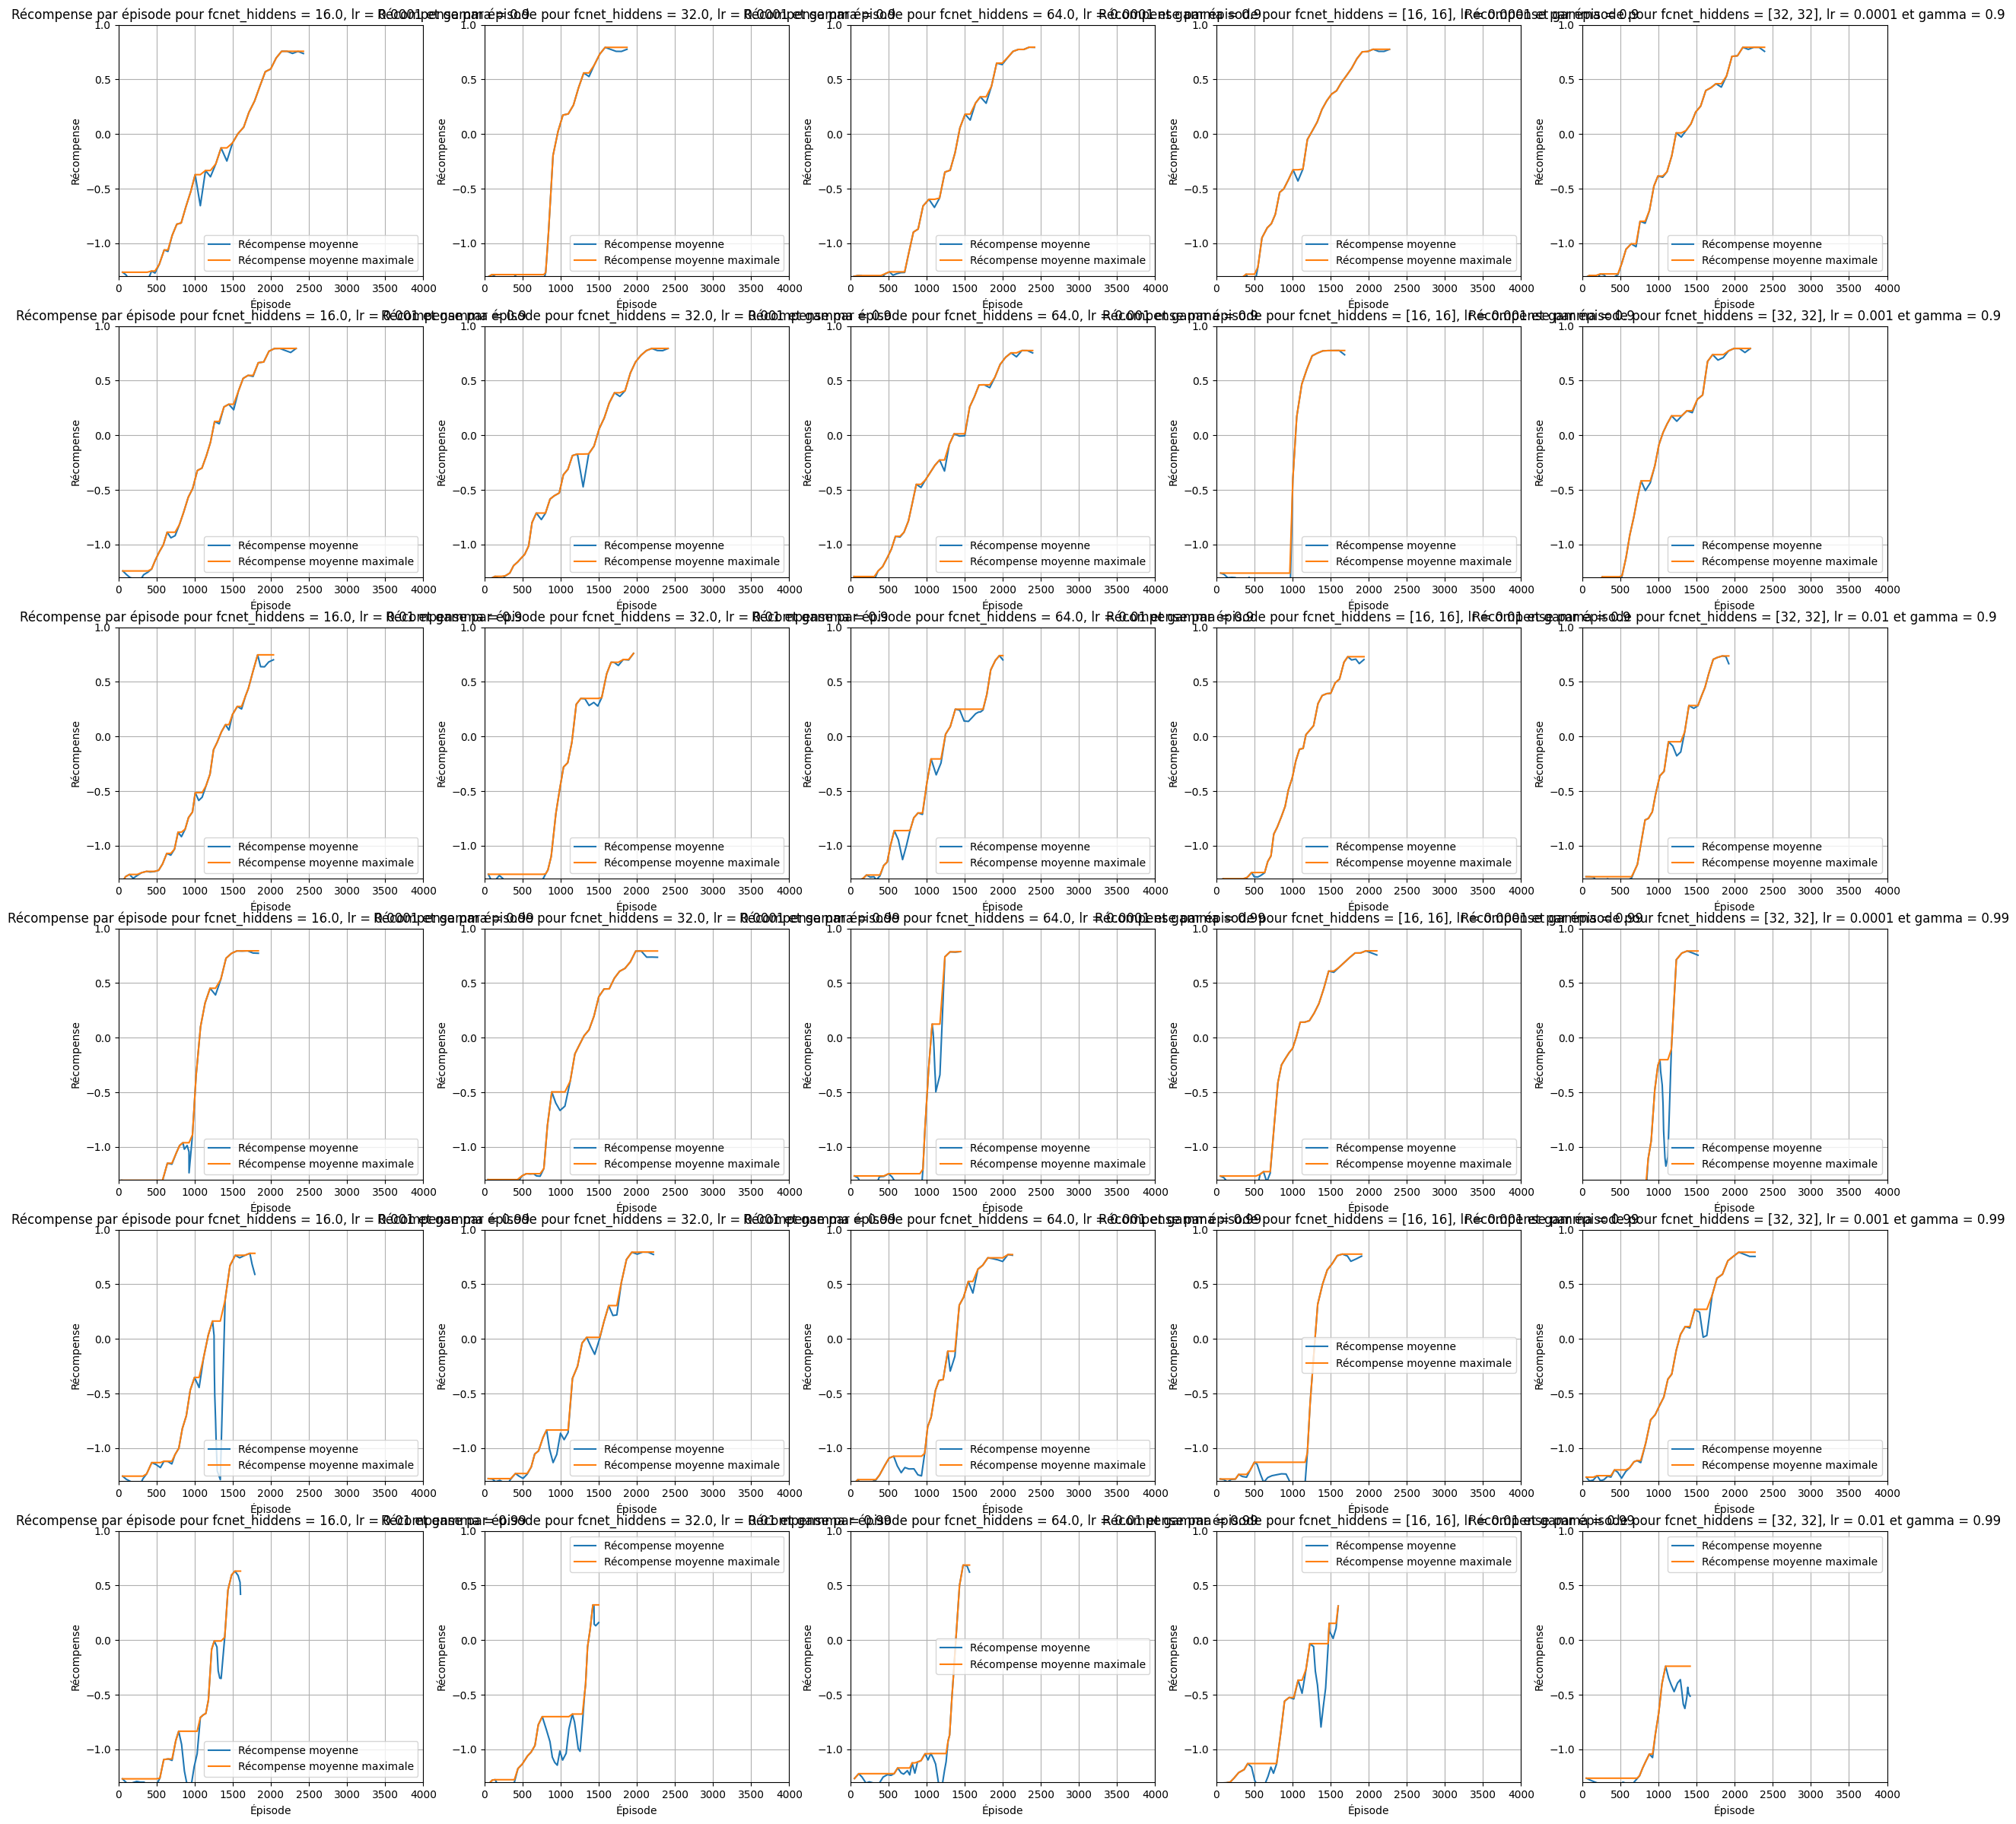

In [4]:
comparison_plot_3(results,
                  "fcnet_hiddens", [16., 32., 64., [16, 16], [32, 32]],
                  "lr", [0.0001, 0.001, 0.01],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -1.3, 1
                 )

Meilleur résultat pour :

- Architecture de [32]
- lr de 0.0001
- gamma de 0.99

# Comparaison entre les divers environnements

2025-06-17 17:21:43,703	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html


.FFF
FFFF
HFFF
HFFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

.HFFFF
FFFFHF
FHHFHF
HFFFFF
FFFHFF
FFFFHG



2025-06-17 17:37:08,970	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-17 17:40:59,719	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-17 17:44:51,555	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-17 17:48:43,287	WARNING util.py:61 -- Install gputil for GPU system monitoring.


.FHFFFHF
FFHFFHFF
FFFFHFFF
FHFFFFFF
FFFFFFFF
HFHFFFFF
FFHFFHFF
FFFFFFFG



2025-06-17 17:52:35,622	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-17 17:56:25,404	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-17 18:00:16,642	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-17 18:04:07,890	WARNING util.py:61 -- Install gputil for GPU system monitoring.
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7815348c56a0>>
Traceback (most recent call last):
  File "/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 

KeyboardInterrupt


KeyboardInterrupt



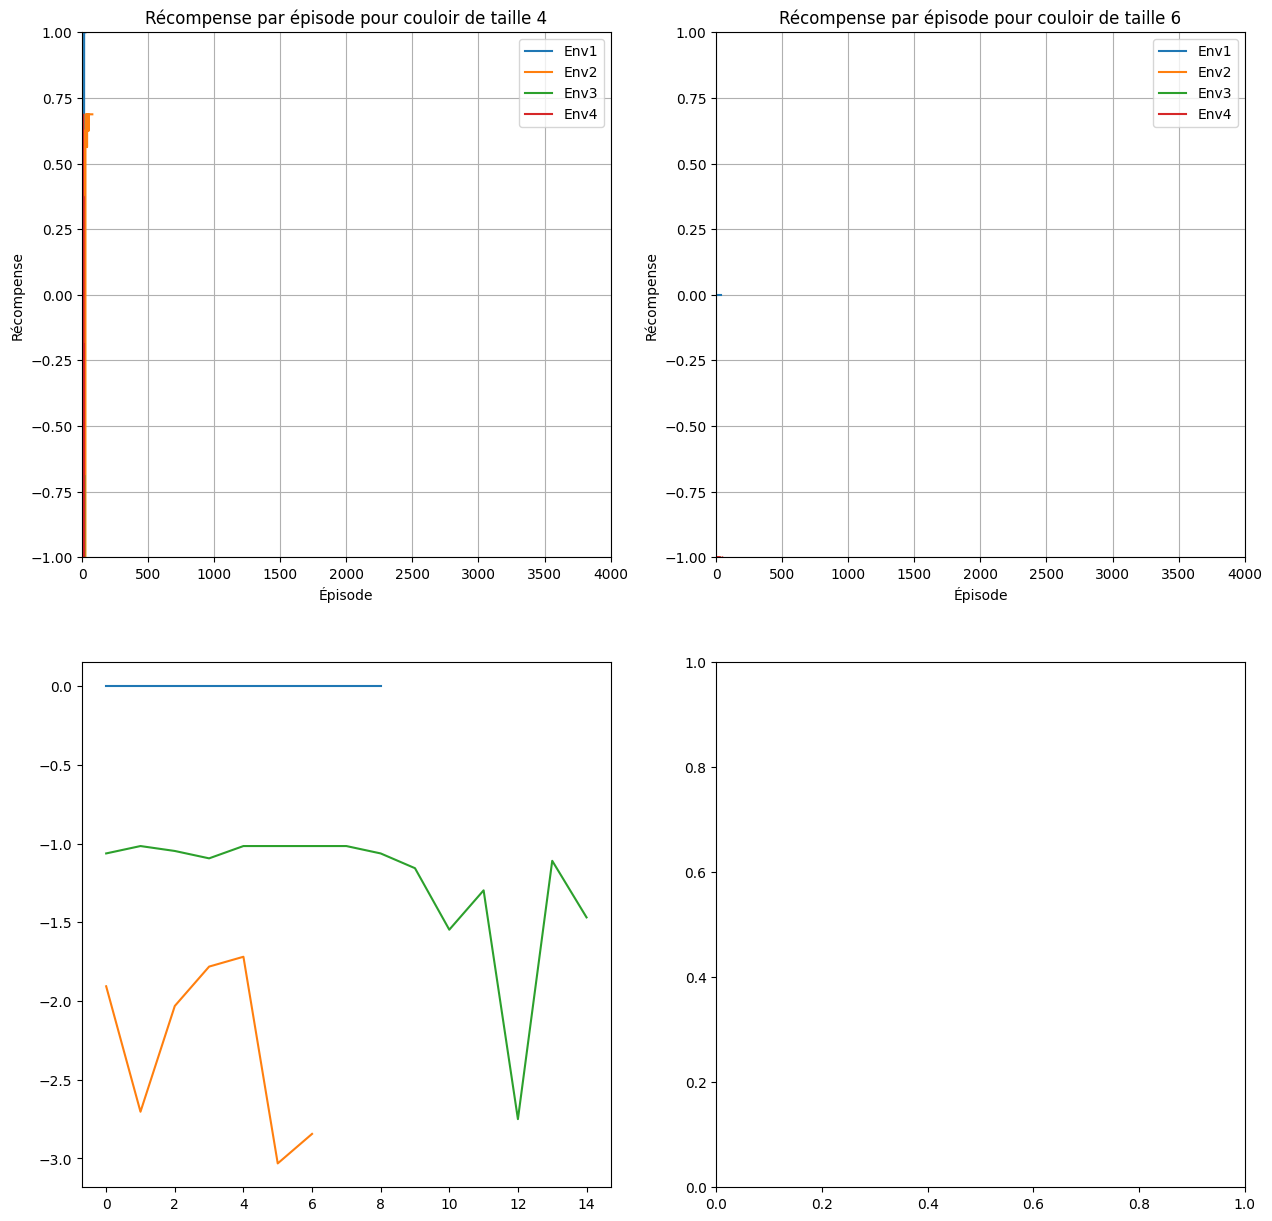

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
data = [(4, 0, 0, 2000), (6, 0, 1, 2000), 
        (8, 1, 0, 2000), (10, 1, 1, 2000)]


for size, x, y, timesteps in data :

    lake_map = generate_random_map(size)
    env = FrozenLakeEnv({'lake_map' : lake_map})
    env.render()

    # First env
    
    config = (
        DQNConfig()
        .environment(
            FrozenLakeEnv,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
        )
    
            .training(
            lr = 0.0001,
            gamma = 0.99,
            target_network_update_freq = 50,
            train_batch_size_per_learner = 1000,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
            replay_buffer_config = {
                "capacity" : 10000
            },
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [32]
            }
        )

    )

    algo = config.build_algo()
    for _ in range(timesteps // 1000):
        resu = algo.train()
    axes[x, y].plot(resu['env_runners']['episodes_rewards'], label = 'Env1')
    algo.stop()



    # Second env

    config = (
        DQNConfig()
        .environment(
            FrozenLake2Env,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
        )
    
            .training(
            lr = 0.0001,
            gamma = 0.99,
            target_network_update_freq = 50,
            train_batch_size_per_learner = 1000,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
            replay_buffer_config = {
                "capacity" : 10000
            },
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [32]
            }
        )

    )

    algo = config.build_algo()
    for _ in range(timesteps // 1000):
        resu = algo.train()
    axes[x, y].plot(resu['env_runners']['episodes_rewards'], label = 'Env2')
    algo.stop()


    # Troisième env

    config = (
        DQNConfig()
        .environment(
            FrozenLake2Env,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
        )
    
            .training(
            lr = 0.0001,
            gamma = 0.99,
            target_network_update_freq = 50,
            train_batch_size_per_learner = 1000,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
            replay_buffer_config = {
                "capacity" : 10000
            },
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [32]
            }
        )

    )

    algo = config.build_algo()
    for _ in range(timesteps // 1000):
        resu = algo.train()
    axes[x, y].plot(resu['env_runners']['episodes_rewards'], label = 'Env3')
    algo.stop()


    # env 4

    config = (
        DQNConfig()
        .environment(
            FrozenLake2Env,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
        )
    
            .training(
            lr = 0.0001,
            gamma = 0.99,
            target_network_update_freq = 50,
            train_batch_size_per_learner = 1000,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
            replay_buffer_config = {
                "capacity" : 10000
            },
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [32]
            }
        )

    )

    algo = config.build_algo()
    for _ in range(timesteps // 1000):
        resu = algo.train()
    axes[x, y].plot(resu['env_runners']['episodes_rewards'], label = 'Env4')
    algo.stop()

    axes[x, y].legend()
    axes[x ,y].set_xlabel("Épisode")
    axes[x ,y].set_ylabel("Récompense")
    axes[x ,y].set_title(f"Récompense par épisode pour couloir de taille {size}")
    axes[x ,y].grid()
    axes[x ,y].set_xlim([0, 4000])
    axes[x ,y].set_ylim([-1, 1])
plt.show()
